In [1]:
from pathlib import Path
import sys
import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from SysSimX.core.base import CoSimComponent
from SysSimX.core.events import Event
from SysSimX.system.system import System
from SysSimX.system.connection import Connection, EventConnection
from SysSimX.viz.sysgraph import SystemGraphVisualizer

from docs.plot_setup import set_professional_style
plt = set_professional_style()

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.FEM import pendulum_config as config
from MyModels.EQB.hybrid_fmu_pendulum import Pendulum as EQBPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque, constant_torque, zero_torque

In [2]:
# FMU Pendulum
eqb_pendulum     = EQBPendulum(name="EQB_Pendulum")

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum = FEMPendulum(name="FEM_Pendulum", group="Plant")
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3)  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 5
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_pendulum.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params
)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end


In [3]:
def wall_contact_indicator(comp: CoSimComponent) -> float:
    theta = comp.get_outputs()['q']
    threshold = np.deg2rad(0)  # 0 degrees in radians
    return theta - threshold

event = Event(name="wall_hit", source=pendulum.name, direction=-1)
pendulum.initialize(0.0)
pendulum.add_event_indicator(event.name, wall_contact_indicator, event.direction)
pendulum.subscribe_event(event)

system = System(name="Master Pendulum System")
system.add_component(pendulum)

event_connection = EventConnection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs['wall_hit'].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs['omega_invert'].name
)

system.add_event_connection(event_connection)
system.initialize(0.0)

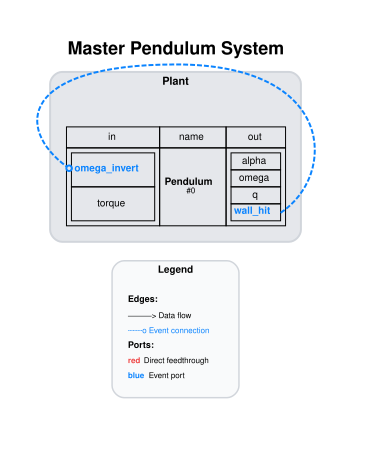

In [4]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [5]:
system.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()
pendulum._update_output_states(t=0)

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [6]:
t_start = 0.0
t_end = 1.0
dt = 0.01  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

[Pendulum] Switching: EQB to OpenSim @ t=0.1500s
[Pendulum] Switching: OpenSim to FEM @ t=0.3600s
  Internal hint from Pendulum: wall_hit in [0.43630000, 0.43640000]

Events detected in interval [0.43000000, 0.44000000]
Crossings: [('Pendulum', 'wall_hit')]
Internal hints: [('Pendulum', ['wall_hit'])]
  Using internal hint to narrow interval: [0.43000000, 0.44000000] -> [0.43630000, 0.43640000]
Located at t=(0.43634209, 0)
Already handled events: set()

Handling events at (0.43634209, 0): [('Pendulum', 'wall_hit')]

Events grouped by component for handling: {'Pendulum': ['wall_hit']}

Dispatching event 'wall_hit' from 'Pendulum' to targets: ['Pendulum']
[FEM_Pendulum] Event 'wall_hit' at t=0.4363s.

[Pendulum] Switching: FEM to OpenSim @ t=0.5200s
[Pendulum] Switching: OpenSim to EQB @ t=0.7300s


In [7]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history['Pendulum']
event_history = history['Events']

t_vals, data = pendulum_history
q_vals = data['q']
omega_vals = data['omega']
alpha_vals = data['alpha']

# Get event times
event_times = event_history.get(('Pendulum', 'wall_hit'), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.43634209 s


In [8]:
marker_size = 3
fem_style = {'color': "#063ccf", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'FEM'}
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'OpenSim'}  # Green
eqb_style = {'color': "#24aa09", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'EQB'}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict['alpha']
    omega_vals[mode] = res_dict['omega']
    q_vals[mode]     = res_dict['q']

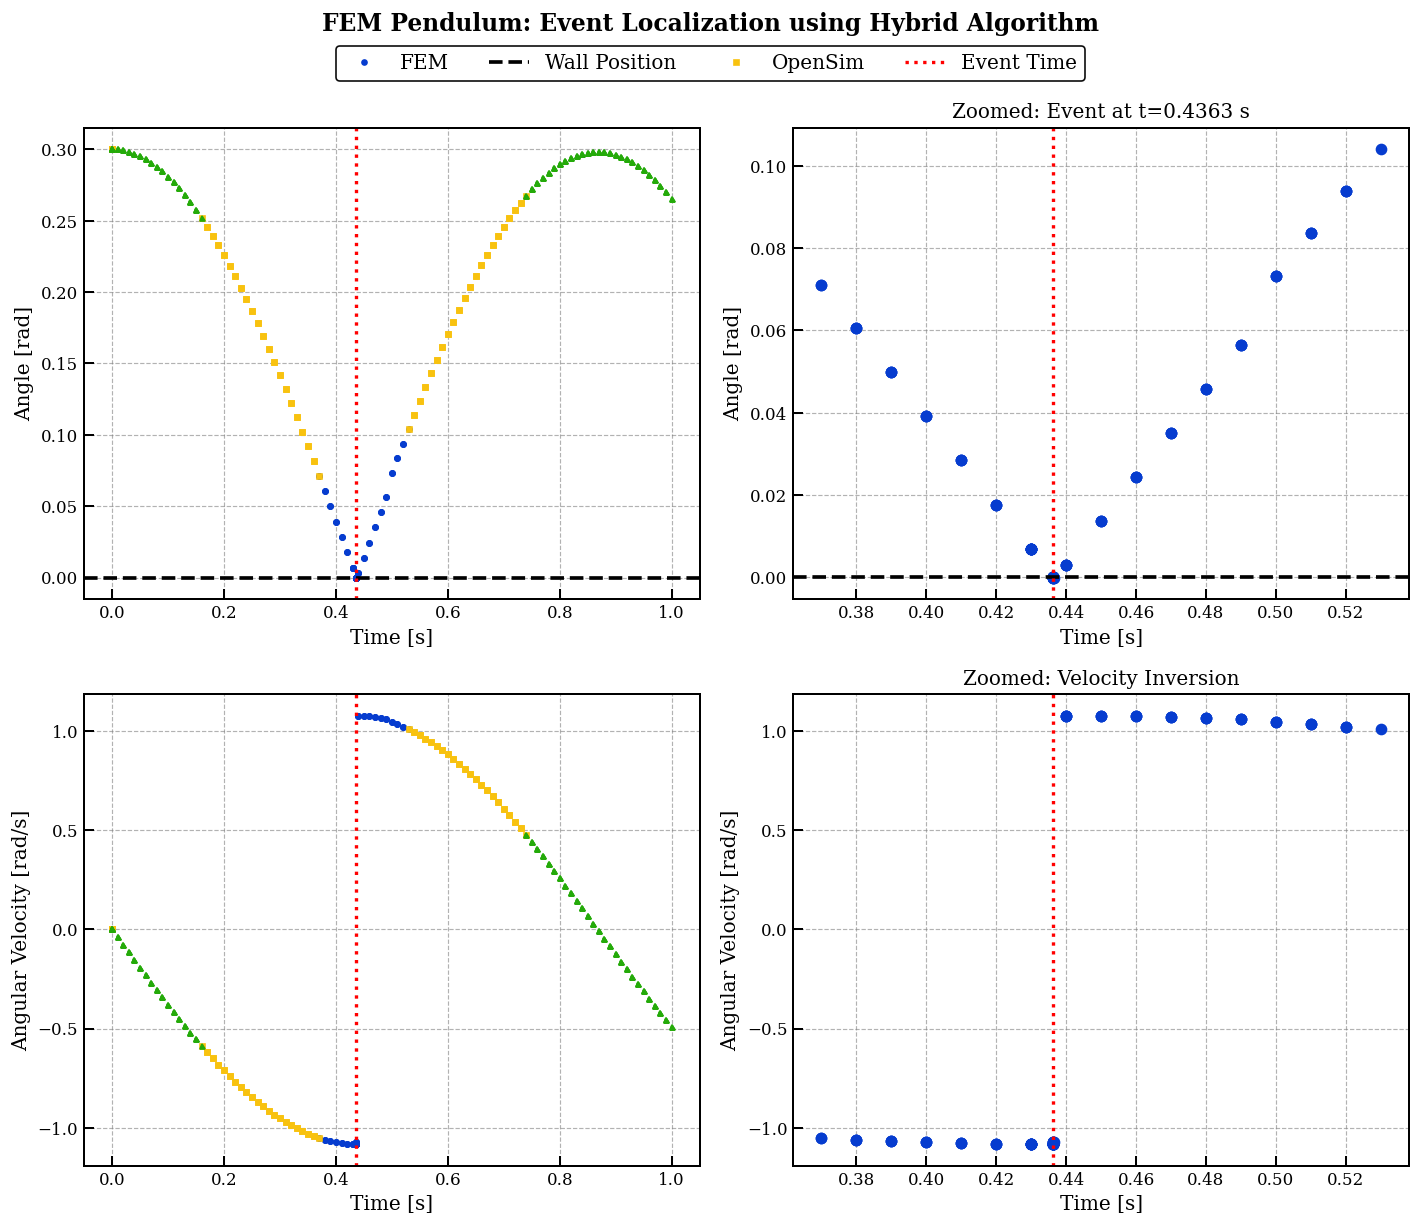

In [10]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('FEM Pendulum: Event Localization using Hybrid Algorithm', 
             fontweight='bold', fontsize=14, y=1.02)

# Top left: Full angle trajectory
line1, = axs[0, 0].plot(t_vals['FEM'], q_vals['FEM'], **fem_style)
line2, = axs[0, 0].plot(t_vals['OpenSim'], q_vals['OpenSim'], **opensim_style)
line3, = axs[0, 0].plot(t_vals['EQB'], q_vals['EQB'], **eqb_style)
line4  = axs[0, 0].axhline(0, color='k', linestyle='--', label='Wall Position')
if t_event:
    line3 = axs[0, 0].axvline(t_event.t, color='red', linestyle=':', linewidth=2, 
                      label=f'Event Time')
axs[0, 0].set_xlabel('Time [s]')
axs[0, 0].set_ylabel('Angle [rad]')
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.1
    mask = (t_vals['FEM'] >= t_event.t - zoom_window) & (t_vals['FEM'] <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals['FEM'][mask], q_vals['FEM'][mask], 'o', markersize=6, color='#063ccf')
    axs[0, 1].axhline(0, color='k', linestyle='--')
    axs[0, 1].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
    axs[0, 1].set_xlabel('Time [s]')
    axs[0, 1].set_ylabel('Angle [rad]')
    axs[0, 1].set_title(f'Zoomed: Event at t={t_event.t:.4f} s')
    axs[0, 1].grid()

# Bottom left: Full angular velocity
line5, = axs[1, 0].plot(t_vals['FEM'], omega_vals['FEM'], **fem_style)
line6, = axs[1, 0].plot(t_vals['OpenSim'], omega_vals['OpenSim'], **opensim_style)
line7, = axs[1, 0].plot(t_vals['EQB'], omega_vals['EQB'], **eqb_style)

if t_event:
    axs[1, 0].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].set_ylabel('Angular Velocity [rad/s]')
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals['FEM'][mask], omega_vals['FEM'][mask], 'o', color='#063ccf', markersize=6)
    axs[1, 1].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
    axs[1, 1].set_xlabel('Time [s]')
    axs[1, 1].set_ylabel('Angular Velocity [rad/s]')
    axs[1, 1].set_title('Zoomed: Velocity Inversion')
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]#, line5]
labels =  [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=5)

plt.tight_layout()
plt.savefig('../figures/Hybrid/test_2_location_FEM.svg')
plt.show()